Customer Segmentation for Retail Store using K-Means Clustering

It includes:

✔ Data Cleaning
✔ Full EDA (graphs + insights)
✔ Feature Selection
✔ Scaling
✔ Elbow Method
✔ K-Means Clustering
✔ Cluster Visualization
✔ Business Insights

Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


Load Data

In [3]:
import pandas as pd

data = pd.read_csv("Mall_Customers.csv")

print(data.head())

                            Customer ID  Age  Gender  Annual Income  \
0  d410ea53-6661-42a9-ad3a-f554b05fd2a7   30    Male         151479   
1  1770b26f-493f-46b6-837f-4237fb5a314e   58  Female         185088   
2  e81aa8eb-1767-4b77-87ce-1620dc732c5e   62  Female          70912   
3  9795712a-ad19-47bf-8886-4f997d6046e3   23    Male          55460   
4  64139426-2226-4cd6-bf09-91bce4b4db5e   24    Male         153752   

   Spending Score  
0              89  
1              95  
2              76  
3              57  
4              76  


Data Understanding (EDA)

In [4]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB
None
                Age  Annual Income  Spending Score
count  15079.000000   15079.000000    15079.000000
mean      54.191591  109742.880562       50.591617
std       21.119207   52249.425866       28.726977
min       18.000000   20022.000000        1.000000
25%       36.000000   64141.000000       26.000000
50%       54.000000  109190.000000       51.000000
75%       72.000000  155008.000000       75.000000
max       90.000000  199974.000000      100.000000


Check Missing Values

In [5]:
print(data.isnull().sum())

Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64


Univariate Analysis

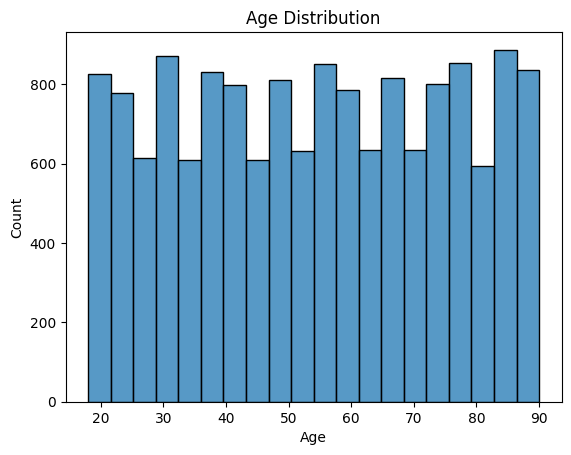

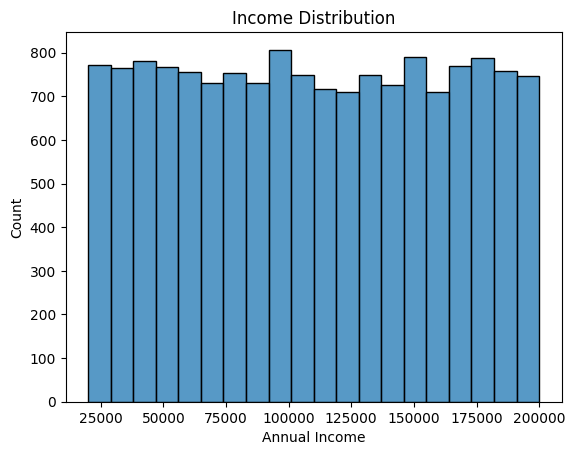

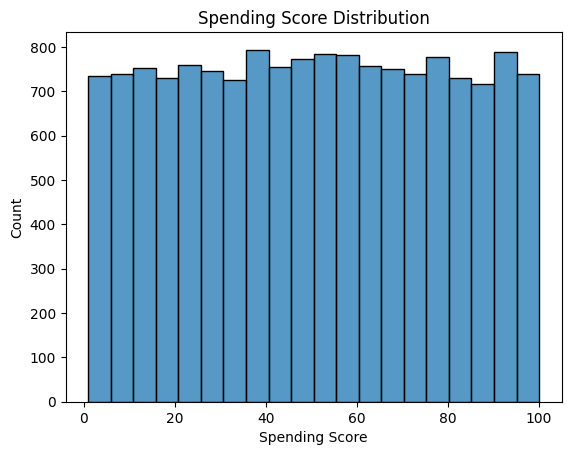

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Age Distribution
sns.histplot(data['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

# Income Distribution
sns.histplot(data['Annual Income'], bins=20)
plt.title("Income Distribution")
plt.show()

# Spending Score Distribution
sns.histplot(data['Spending Score'], bins=20)
plt.title("Spending Score Distribution")
plt.show()

Bivariate Analysis

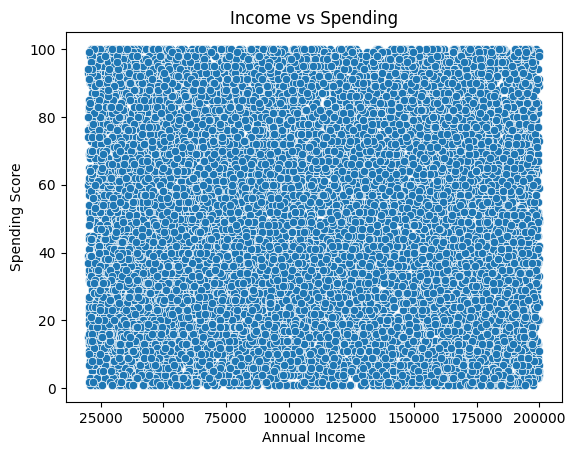

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Annual Income', y='Spending Score', data=data)

plt.title("Income vs Spending")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

Correlation Heatmap

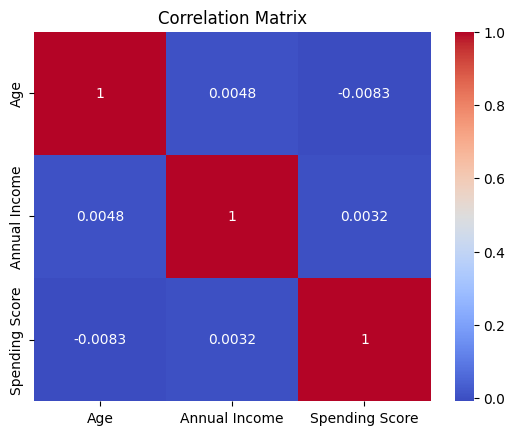

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Correlation heatmap
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Feature Selection

In [17]:
# Always good practice
data.columns = data.columns.str.strip()

# Feature selection
X = data[['Annual Income', 'Spending Score']]

print(X.head())

   Annual Income  Spending Score
0         151479              89
1         185088              95
2          70912              76
3          55460              57
4         153752              76


Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Elbow Method

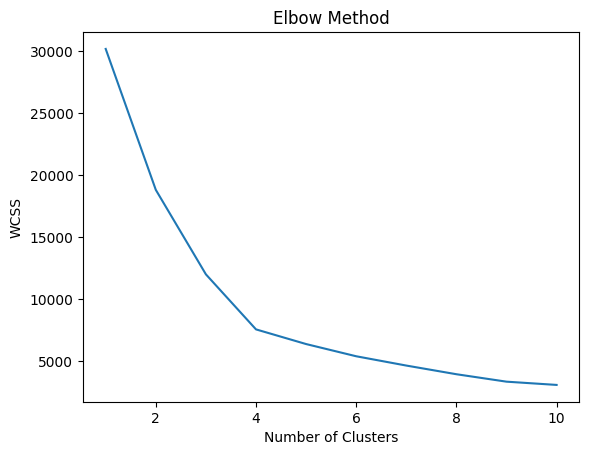

In [19]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Apply K-Means

In [20]:
kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

Cluster Visualization

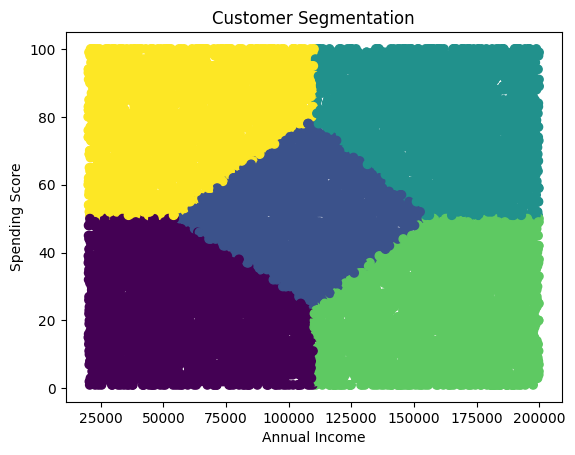

In [22]:
import matplotlib.pyplot as plt

plt.scatter(data['Annual Income'], data['Spending Score'],
            c=data['Cluster'], cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

Cluster Analysis

In [24]:
numeric_data = data.select_dtypes(include=['number'])

cluster_analysis = numeric_data.groupby(data['Cluster']).mean()

print(cluster_analysis)

               Age  Annual Income  Spending Score  Cluster
Cluster                                                   
0        54.262024   59520.105559       22.517177      0.0
1        54.357537  106141.212314       51.450955      1.0
2        54.235948  160272.048796       77.745522      2.0
3        54.331875  160515.649688       23.263437      3.0
4        53.799611   58902.720493       78.930285      4.0
